# Scribble Evaluation — Age Interpolation (40–80)
Load a scribble from Google Drive (job `44490272`), generate conditioned photos,
compute MMD vs age-based target distribution (40–80 yo men),
fit PCA on age-40 vs age-80 embeddings, project everything, and pick 14 photos evenly along the age axis.

## 1. Setup

In [149]:
import os, sys, json, gc, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torchvision.transforms.functional as TF
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from IPython.display import display
from huggingface_hub import login
from google.colab import userdata
import wandb

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass('Enter your GitHub personal access token: ')

    repo_url  = f'https://{token}@github.com/orineo1/conditional-matching-paper.git'
    repo_name = 'conditional-matching-paper'
    branch    = 'SD-add-vis-and-table'

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f'/content/{repo_name}'
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

repo_path = f'/content/{repo_name}/SD_cond_SD_controlnet'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

wandb_token = userdata.get('WANDB')
if wandb_token:
    wandb.login(key=wandb_token)
else:
    wandb.login()

import random

GLOBAL_SEED = 42

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'[Seed] All random seeds set to {seed}')

set_global_seed(GLOBAL_SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Repo 'conditional-matching-paper' already cloned — pulling latest...
Already up to date.
Already on 'SD-add-vis-and-table'
Your branch is up to date with 'origin/SD-add-vis-and-table'.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


[Seed] All random seeds set to 42
Device: cuda


## 2. Config

In [150]:
from google.colab import drive
drive.mount('/content/drive')

# ── Job to evaluate ───────────────────────────────────────────────────────────
JOB_ID           = 44492374
RUNS_ROOT        = '/content/drive/MyDrive/conditional-matching/runs/InterpolationMenWomen'
run_dir          = Path(RUNS_ROOT) / f'dps_main_{JOB_ID}'

# ── Age range ─────────────────────────────────────────────────────────────────
AGE_MIN          = 40     # inclusive
AGE_MAX          = 80     # exclusive  (so 40, 41, ..., 79)
AGE_STEP         = 1
AGES             = list(range(AGE_MIN, AGE_MAX, AGE_STEP))

# PCA anchor ages — used to FIT the age axis
PCA_YOUNG_AGE    = 40     # youngest anchor
PCA_OLD_AGE      = 79     # oldest anchor
N_PCA_ANCHOR     = 10     # how many images to use per anchor when fitting PCA

# Number of picks to display along the age axis
NUM_PICKS        = 14

# Generation params
CONTROLNET_SCALE = 0.5
N_EVAL           = 100    # eval photos from the LGD-CM scribble
N_TARGETS_PER_AGE = 3     # images per age used to build target CLIP embeddings
EVAL_PROMPT      = 'a superrealistic professional photograph of'

print(f'Job: {JOB_ID}')
print(f'Age range: {AGE_MIN}–{AGE_MAX-1}  ({len(AGES)} ages)')
print(f'PCA anchors: age {PCA_YOUNG_AGE} vs age {PCA_OLD_AGE}  ({N_PCA_ANCHOR} each)')
print(f'Picks along age axis: {NUM_PICKS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Job: 44492374
Age range: 40–79  (40 ages)
PCA anchors: age 40 vs age 79  (10 each)
Picks along age axis: 14


## 3. Load Models

In [151]:
from models     import load_models
from clip_utils import load_clip_model

architect, sprinter        = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print('Models loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


## 4. Helpers

In [152]:
from generation    import generate_and_store_cs
from clip_utils    import encode_images_clip
from visualization import plot_row
from metrics       import compute_mmd

def pil_to_tensor(pil_list):
    return torch.cat(
        [TF.to_tensor(img).unsqueeze(0) for img in pil_list], dim=0
    ).to(next(clip_model.parameters()).device)


def generate_eval_photos(scribble_pil, n=N_EVAL, seed=None):
    sprinter.vae.to(dtype=torch.float16)
    generator = None
    if seed is not None:
        generator = torch.Generator(device=sprinter.device).manual_seed(seed)
    photos = []
    with torch.no_grad():
        for start in range(0, n, 2):
            bs = min(2, n - start)
            result = sprinter(
                prompt=[EVAL_PROMPT] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='pil',
                generator=generator,
            )
            photos.extend(result.images)
    sprinter.vae.to(dtype=torch.float32)
    return photos


def encode_age_prompt(age):
    """Return the text prompt used during target generation for a given age."""
    return (
        f'a superrealistic portrait photograph of a {age}-year-old man, '
        'studio lighting, sharp focus, photographic'
    )


print('Helpers ready.')

Helpers ready.


## 5. Load Scribble from Run

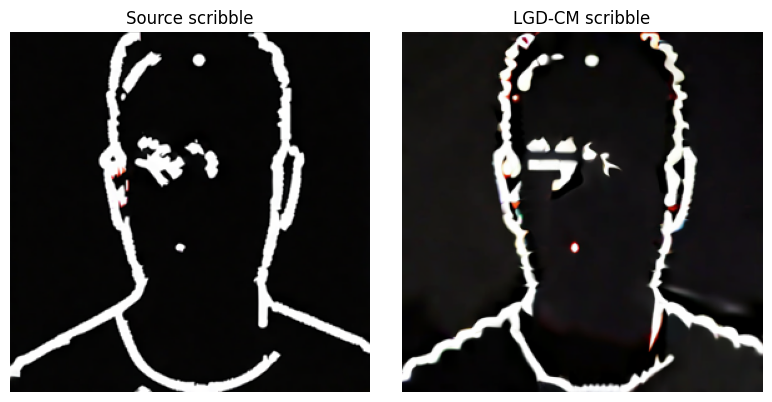

Loaded scribble from /content/drive/MyDrive/conditional-matching/runs/InterpolationMenWomen/dps_main_44492374


In [170]:
lgd_img    = Image.open(run_dir / 'final_scribble_lgd_cm.png')
scribble_arr = np.load(run_dir / 'npy' / 'scribble.npy')
run_dir / 'npy' / 'source_protrait.npy'
source_scribble = Image.fromarray(scribble_arr[0] if scribble_arr.ndim == 4 else scribble_arr)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, img, title in zip(
    axes,
    [source_scribble, lgd_img],
    ['Source scribble', 'LGD-CM scribble'],
):
    ax.imshow(img); ax.axis('off'); ax.set_title(title)
plt.tight_layout(); display(fig); plt.close()

scribble_pil = lgd_img
print(f'Loaded scribble from {run_dir}')

## 6. Build Age Target Distribution & Encode to CLIP

In [ ]:
from sklearn.decomposition import PCA

print(f'Building age target embeddings ({len(AGES)} ages × {N_TARGETS_PER_AGE} = {len(AGES)*N_TARGETS_PER_AGE} images)...')

age_clip_embs = {}   # age -> Tensor [N_TARGETS_PER_AGE, 768]

clip_model.to(device)
with torch.no_grad():
    for age in AGES:
        prompt = encode_age_prompt(age)
        imgs, _ = generate_and_store_cs(
            sprinter, prompt, scribble_pil,
            N_TARGETS_PER_AGE, batch_size=2, cn_scale=CONTROLNET_SCALE,
            seed=GLOBAL_SEED + age * 7,
        )
        embs = encode_images_clip(pil_to_tensor(imgs), clip_model, clip_processor)
        age_clip_embs[age] = embs.cpu()
        # print(f'  age {age:3d}: done', flush=True)
clip_model.to('cpu')

# Flat target tensor for MMD  [N_ages × N_per_age, 768]
all_clip_embeddings = torch.cat([age_clip_embs[a] for a in AGES], dim=0).to(device)
age_labels_arr      = np.array([a for a in AGES for _ in range(N_TARGETS_PER_AGE)])

print(f'\nTarget CLIP embeddings: {all_clip_embeddings.shape}')
norms = all_clip_embeddings.norm(dim=-1)
print(f'Norms min/max: {norms.min():.4f} / {norms.max():.4f}')

## 7. Fit PCA on Age-40 vs Age-79 (anchors), Project All Ages

PCA fitted on age-40 vs age-79
PC1 variance: 60.9%   PC2: 13.3%


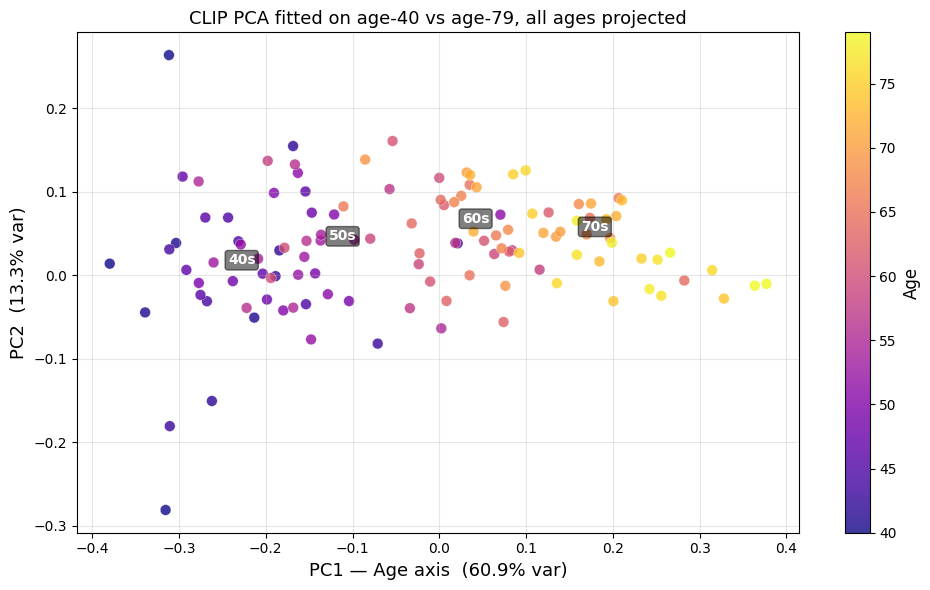

In [155]:
# ── Gather anchor embeddings ──────────────────────────────────────────────────
young_np = age_clip_embs[PCA_YOUNG_AGE].numpy()[:N_PCA_ANCHOR]   # age 40
old_np   = age_clip_embs[PCA_OLD_AGE].numpy()[:N_PCA_ANCHOR]     # age 79

# ── Fit 2-D PCA on the two anchor groups only ─────────────────────────────────
pca = PCA(n_components=2)
pca.fit(np.vstack([young_np, old_np]))

# Orient PC1 so that older → positive
young_2d = pca.transform(young_np)
old_2d   = pca.transform(old_np)
flip     = -1 if old_2d[:, 0].mean() < young_2d[:, 0].mean() else 1

def project(embs_np):
    coords = pca.transform(embs_np)
    coords[:, 0] *= flip
    return coords

print(f'PCA fitted on age-{PCA_YOUNG_AGE} vs age-{PCA_OLD_AGE}')
print(f'PC1 variance: {pca.explained_variance_ratio_[0]:.1%}   PC2: {pca.explained_variance_ratio_[1]:.1%}')

# ── Quick sanity plot: all target ages coloured by age ────────────────────────
all_target_np = all_clip_embeddings.cpu().numpy()
all_target_2d = project(all_target_np)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    all_target_2d[:, 0], all_target_2d[:, 1],
    c=age_labels_arr, cmap='plasma',
    s=60, alpha=0.8, edgecolors='white', linewidths=0.3,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Age', fontsize=12)

# Annotate decade centroids
for decade_age in range(40, 80, 10):
    decade_mask = (age_labels_arr >= decade_age) & (age_labels_arr < decade_age + 10)
    cx, cy = all_target_2d[decade_mask].mean(0)
    ax.annotate(
        str(decade_age) + 's', (cx, cy),
        textcoords='offset points', xytext=(0, 6),
        fontsize=10, ha='center', fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5),
    )

ax.set_xlabel(f'PC1 — Age axis  ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=13)
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=13)
ax.set_title(
    f'CLIP PCA fitted on age-{PCA_YOUNG_AGE} vs age-{PCA_OLD_AGE}, all ages projected',
    fontsize=13,
)
ax.grid(True, alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

## 8. Generate Eval Photos from LGD-CM Scribble

In [156]:
print(f'Generating {N_EVAL} eval photos from LGD-CM scribble...')
eval_photos = generate_eval_photos(scribble_pil, n=N_EVAL, seed=GLOBAL_SEED)

Generating 100 eval photos from LGD-CM scribble...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


## 9. Project Eval Photos onto Age Axis & Score

In [157]:
clip_model.to(device)
with torch.no_grad():
    eval_embs = encode_images_clip(
        pil_to_tensor(eval_photos), clip_model, clip_processor
    )
# clip_model.to('cpu')


In [158]:
eval_np   = eval_embs.cpu().numpy()
eval_2d   = project(eval_np)

# PC1 score (already oriented so older = positive)
age_scores  = eval_2d[:, 0]
sorted_idx  = np.argsort(age_scores)   # youngest-looking → oldest-looking

print(f'Age-axis scores:  min={age_scores.min():.3f}  max={age_scores.max():.3f}')

Age-axis scores:  min=-0.241  max=0.355


## 10. Pick 14 Photos

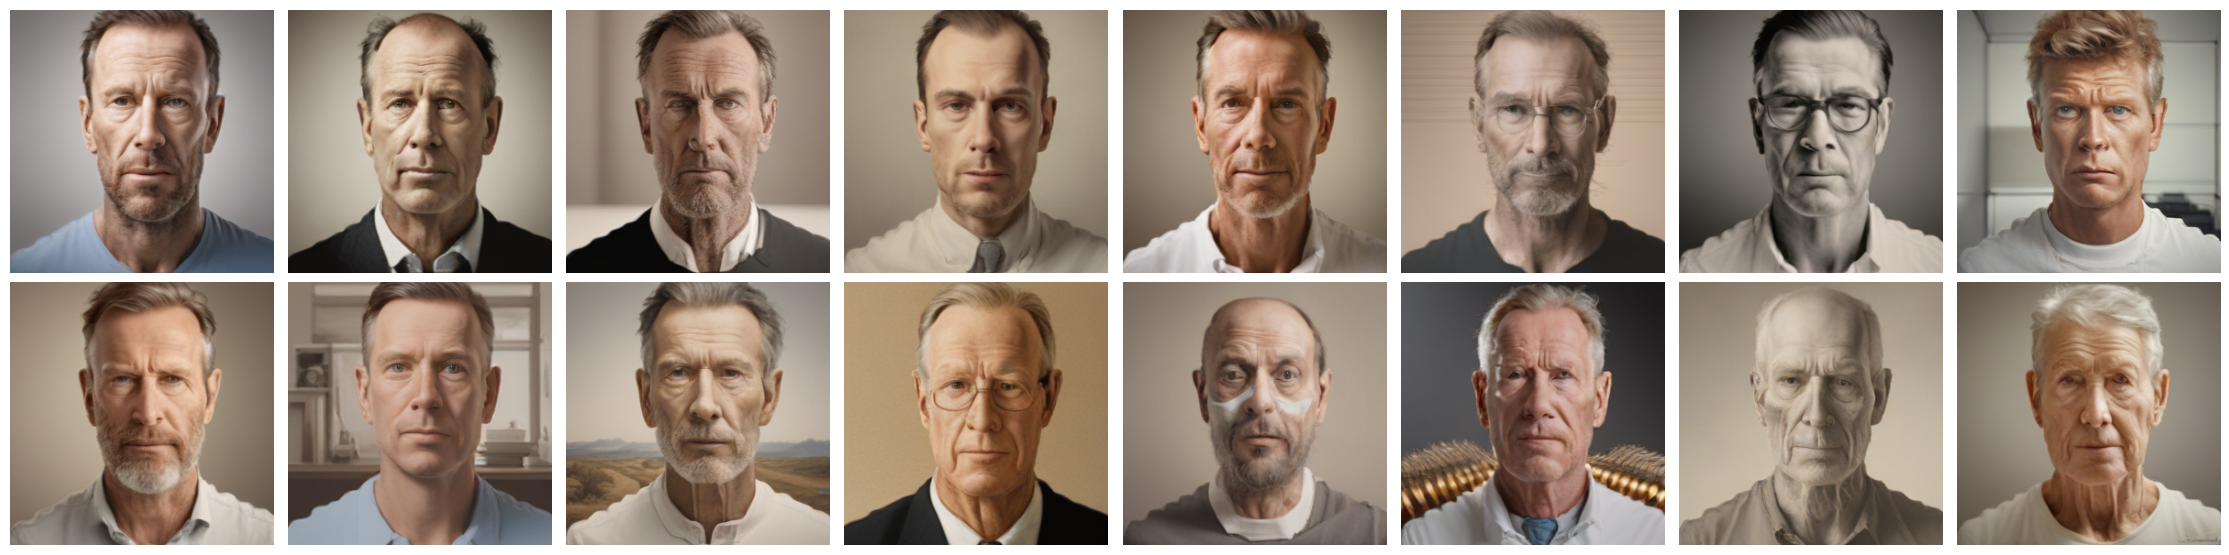

In [159]:
n_eval = len(eval_photos)
NUM_PICKS=16
# Evenly spaced indices in sorted order
picks = [
    sorted_idx[int(i * (n_eval - 1) / (NUM_PICKS - 1))]
    for i in range(NUM_PICKS)
]

fig, axes = plt.subplots(2, NUM_PICKS // 2, figsize=(NUM_PICKS * 1.4, 6))
for ax, idx in zip(axes.flatten(), picks):
    score = age_scores[idx]
    ax.imshow(eval_photos[idx])
    # ax.set_title(f'{score:.2f}', fontsize=8)
    ax.axis('off')

axes[0, 0].set_xlabel(f'')
axes[0, -1].set_xlabel(f'')
fig.suptitle(
    f'',
    fontsize=12,
)
plt.tight_layout(); display(fig); plt.close()

## 11. Full PCA Scatter: Target Ages + Eval Photos

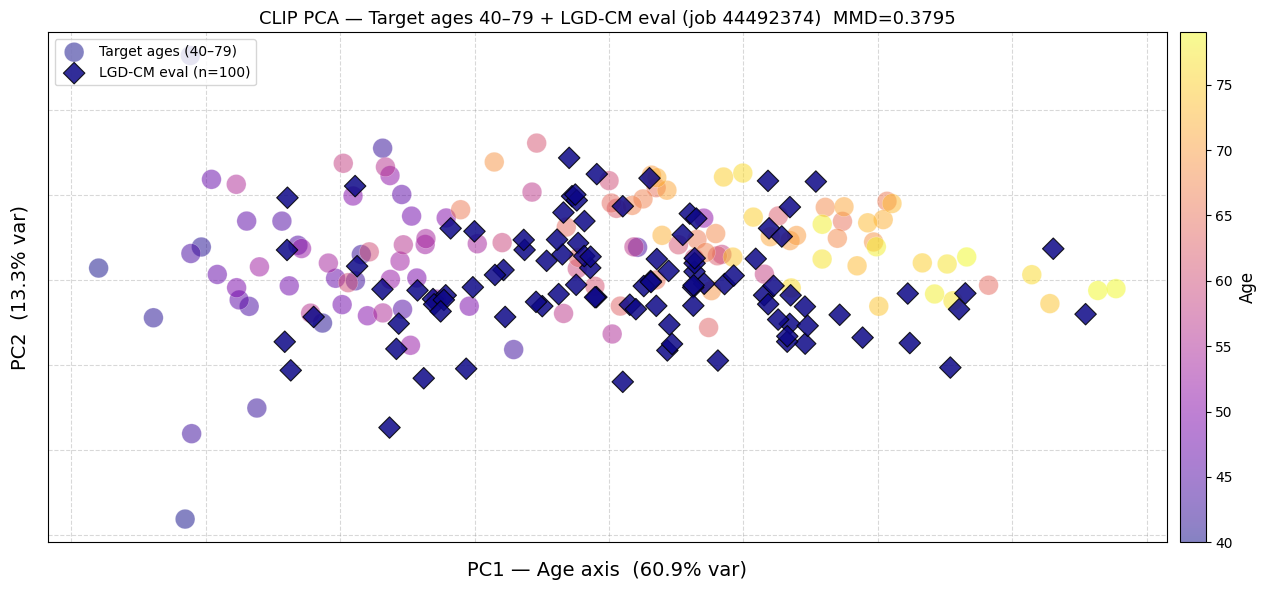

In [160]:
cmap_age = cm.plasma

fig, ax = plt.subplots(figsize=(14, 6))

sc = ax.scatter(
    all_target_2d[:, 0], all_target_2d[:, 1],
    c=age_labels_arr, cmap=cmap_age,
    s=200, alpha=0.5,
    edgecolors='white', linewidths=0.3,
    label='Target ages (40–79)',
)
cbar = fig.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Age', fontsize=12)

ax.scatter(
    eval_2d[:, 0], eval_2d[:, 1],
    c=age_scores, cmap=cmap_age,
    s=120, alpha=0.85, marker='D',
    edgecolors='black', linewidths=0.8,
    vmin=age_labels_arr.min(), vmax=age_labels_arr.max(),
    label=f'LGD-CM eval (n={n_eval})',
    zorder=5,
)

ax.set_xlabel(f'PC1 — Age axis  ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=14, labelpad=10)
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=14, labelpad=10)
ax.set_xticklabels([]); ax.set_yticklabels([])
ax.tick_params(axis='both', which='both', length=0)
ax.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='upper left')
ax.set_title(
    f'CLIP PCA — Target ages 40–79 + LGD-CM eval (job {JOB_ID})  MMD={mmd_val:.4f}',
    fontsize=13,
)
plt.tight_layout(); display(fig); plt.close()

## 9. Compute MMD vs Target

In [161]:
N_MMD = 2000

print(f'Generating {N_MMD} photos for MMD computation...')
mmd_photos = generate_eval_photos(scribble_pil, n=N_MMD, seed=GLOBAL_SEED + 1)

clip_model.to(device)
# Encode in chunks to avoid OOM
chunk_size = 50
all_mmd_embs = []
with torch.no_grad():
    for start in range(0, N_MMD, chunk_size):
        chunk = mmd_photos[start:start + chunk_size]
        embs = encode_images_clip(pil_to_tensor(chunk), clip_model, clip_processor)
        all_mmd_embs.append(embs)
        print(f'  Encoded {min(start + chunk_size, N_MMD)}/{N_MMD}', end='\r')
eval_embs = torch.cat(all_mmd_embs, dim=0)
clip_model.to('cpu')

with torch.no_grad():
    mmd_val = compute_mmd(eval_embs, all_clip_embeddings).item()

print(f'\nMMD (eval photos vs age-{AGE_MIN}–{AGE_MAX-1} target): {mmd_val:.6f}')

Generating 2000 photos for MMD computation...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(



MMD (eval photos vs age-40–79 target): 0.379491
